# Calculate the metrics from the csv

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from evaluation_utils import bootstrap_from_csv

# Define models and their respective CSV paths
models_to_test = {
    "DINOv2": "csvs/dinov2_closed_v1/closed_dist_matrix.csv",
    "SwinV2": "csvs/swinv2_closed_v1/closed_dist_matrix.csv",
    "ViT": "csvs/vit_closed_v1/closed_dist_matrix.csv"
}

all_results = {}

# Run bootstrap for each
for name, path in models_to_test.items():
    print(f"\n{'='*30}\nProcessing {name}\n{'='*30}")
    all_results[name] = bootstrap_from_csv(path, m=10, mode="closed")


Processing DINOv2
-> Bootstrapping closed metrics from CSV (10 iterations)...


100%|██████████| 10/10 [00:08<00:00,  1.19it/s]


Bootstrap Results (Closed-Set):
mAP: 41.34% ± 0.82%
Rank-1: 43.76% [41.64% - 45.28%]

Processing SwinV2


FileNotFoundError: [Errno 2] No such file or directory: 'csvs/swinv2_closed_v1/closed_dist_matrix.csv'

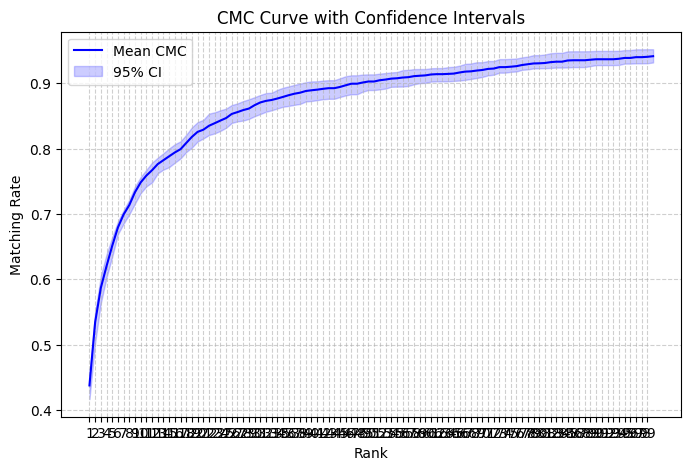

In [ ]:
# 2. Plotting the CMC Curves
plt.figure(figsize=(10, 6))

for name, res in all_results.items():
    ranks = res['ranks'][:20]  # Look at top 20 ranks
    mean_cmc = res['cmc_mean'][:20]
    lower = res['cmc_lower'][:20]
    upper = res['cmc_upper'][:20]
    
    # Plot the mean line
    plt.plot(ranks, mean_cmc, label=f"{name} (mAP: {res['mAP_mean']:.1%})", lw=2)
    
    # Fill the confidence interval (Bootstrap variance)
    plt.fill_between(ranks, lower, upper, alpha=0.2)

plt.xlabel('Rank')
plt.ylabel('Identification Probability')
plt.title('CMC Curve Comparison (with 95% Bootstrap CI)')
plt.xticks(np.arange(1, 21, 1))
plt.grid(ls='--', alpha=0.6)
plt.legend()
plt.ylim([0, 1.05])
plt.show()